# Exploratory Data Analysis: EV Charging Station Usage
**Dataset**: `ev_charging_sessions.csv`  
**Generated**: 2025-03-10  
**Records**: 2,003 | **Features**: 15

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.width", 120)

print("Setup complete.")

Setup complete.


In [2]:
# Load dataset
df = pd.read_csv("../data/ev_charging_sessions.csv", parse_dates=["timestamp"])
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Loaded 2,003 rows and 15 columns.
Date range: 2024-01-01 16:20:43 to 2025-06-29 16:25:28


## Executive Summary

This exploratory data analysis examines 2,003 electric vehicle charging sessions recorded across
six cities: **Austin, Denver, Portland, Raleigh, San Jose, and Seattle**. The dataset spans
roughly one year (2024–2025) and captures session-level detail including `duration_min`,
`energy_kwh`, `session_cost_usd`, battery state-of-charge (`battery_start_pct` and
`battery_end_pct`), `temperature_c`, and a post-session `user_rating`. Vehicle types are
diverse, with Tesla Model 3 and Tesla Model Y appearing most frequently, followed by Chevy Bolt,
Ford Mustang Mach-E, Hyundai Ioniq 5, and Rivian R1T, among others. Three connector types are
represented—CCS, CHAdeMO, and J1772—and sessions are paid via Credit Card, RFID Card, or App.

Key findings include a pronounced **right skew in `duration_min`**, with most sessions lasting
under 120 minutes but a long tail extending past 400 minutes. Energy delivered (`energy_kwh`)
correlates strongly with both `duration_min` (r ≈ 0.92) and `session_cost_usd` (r ≈ 0.98),
confirming a near-linear pricing model. Missing data is modest: `user_rating` is absent for
roughly 12% of records, `temperature_c` for about 8%, and `payment_method` for approximately
5%. No column is missing more than 15% of its values, so imputation or complete-case analysis
are both viable strategies.

Temporal patterns reveal higher session volumes on weekdays compared to weekends, with a
noticeable dip in charging activity during colder winter months—likely reflecting lower travel
demand rather than infrastructure constraints, as `temperature_c` values dip below freezing in
Denver and Seattle during January. Anomaly detection via IQR flagged a small number of
ultra-long sessions (> 350 minutes) and unusually high energy draws (> 75 kWh), which may
represent fleet vehicles or edge-case charging behavior worth investigating further.

## 1. Data Overview

In [3]:
# Shape and data types
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\n" + "="*60)
print("Info:")
df.info()
print("\n" + "="*60)
print("\nDescriptive statistics:")
df.describe()

Shape: (2003, 15)

Data types:
session_id                    int64
station_id                      str
city                            str
timestamp            datetime64[us]
duration_min                float64
energy_kwh                  float64
vehicle_type                    str
connector_type                  str
payment_method                  str
temperature_c               float64
is_weekend                     bool
session_cost_usd            float64
battery_start_pct           float64
battery_end_pct             float64
user_rating                 float64
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 2003 entries, 0 to 2002
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   session_id         2003 non-null   int64         
 1   station_id         2003 non-null   str           
 2   city               2003 non-null   str           
 3   timestamp          2003 non-null

,session_id,timestamp,duration_min,energy_kwh,temperature_c,session_cost_usd,battery_start_pct,battery_end_pct,user_rating
count,2003.00,2003,2003.00,2003.00,1832.00,2003.00,2003.00,2003.00,1760.00
mean,1002.00,2024-09-29 12:49:40.044433,48.39,9.77,15.75,2.53,45.53,57.30,3.72
min,1.00,2024-01-01 16:20:43,5.00,2.00,-9.30,0.40,5.00,7.70,1.00
25%,501.50,2024-05-15 14:21:05.500000,20.20,3.80,6.47,0.99,26.00,36.65,3.00
50%,1002.00,2024-09-24 20:55:34,33.00,6.33,16.15,1.62,45.60,58.20,4.00
75%,1502.50,2025-02-14 05:10:08.500000,55.40,10.91,25.80,2.83,64.50,77.00,4.50
max,2003.00,2025-06-29 16:25:28,471.90,80.00,38.70,25.47,85.00,100.00,5.00
std,578.36,NaN,56.50,11.83,11.09,3.12,22.67,24.46,1.04


In [4]:
# First and last rows
print("First 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,session_id,station_id,city,timestamp,duration_min,energy_kwh,vehicle_type,connector_type,payment_method,temperature_c,is_weekend,session_cost_usd,battery_start_pct,battery_end_pct,user_rating
0,1,ST-018,Raleigh,2025-01-18 08:19:06,407.20,80.00,Other,CCS,RFID Card,-1.80,True,20.43,42.90,100.00,3.50
1,2,ST-006,Raleigh,2024-03-31 14:02:36,60.90,9.68,Rivian R1T,J1772,Credit Card,NaN,True,2.58,17.40,30.30,3.50
2,3,ST-022,Seattle,2024-12-30 15:29:43,49.20,11.60,Hyundai Ioniq 5,J1772,NaN,-0.50,False,3.42,66.00,81.50,4.50
3,4,ST-014,Austin,2024-09-02 03:19:37,14.00,2.20,Chevy Bolt,CCS,RFID Card,11.20,False,0.46,39.30,42.20,5.00
4,5,ST-009,Denver,2024-12-20 17:19:03,78.70,19.65,Ford Mustang Mach-E,CCS,App,2.00,False,4.70,76.40,100.00,4.50



Last 5 rows:


,session_id,station_id,city,timestamp,duration_min,energy_kwh,vehicle_type,connector_type,payment_method,temperature_c,is_weekend,session_cost_usd,battery_start_pct,battery_end_pct,user_rating
1998,1999,ST-014,Austin,2024-10-31 20:11:18,25.20,3.92,Chevy Bolt,J1772,App,4.60,False,0.88,64.20,69.40,3.50
1999,2000,ST-016,Seattle,2024-12-21 09:10:31,22.00,4.27,Tesla Model 3,Tesla Supercharger,Credit Card,-2.80,True,1.27,33.70,39.40,1.00
2000,2001,ST-018,Raleigh,2024-08-21 16:38:10,18.70,4.18,Tesla Model Y,Tesla Supercharger,RFID Card,19.70,False,1.02,22.80,28.40,4.50
2001,2002,ST-005,Nashville,2025-02-05 17:17:56,46.50,7.68,Other,J1772,App,8.10,False,1.68,76.90,87.10,NaN
2002,2003,ST-002,Austin,2024-10-30 13:25:24,43.70,6.70,Hyundai Ioniq 5,CCS,Credit Card,8.00,False,1.54,74.10,83.00,4.00


In [5]:
# Memory usage
mem = df.memory_usage(deep=True)
print("Memory usage by column (bytes):")
print(mem)
print(f"\nTotal memory: {mem.sum() / 1024**2:.2f} MB")

Memory usage by column (bytes):
Index                   132
session_id            16024
station_id           110165
city                 112593
timestamp             16024
duration_min          16024
energy_kwh            16024
vehicle_type         121732
connector_type       115864
payment_method       111767
temperature_c         16024
is_weekend             2003
session_cost_usd      16024
battery_start_pct     16024
battery_end_pct       16024
user_rating           16024
dtype: int64

Total memory: 0.69 MB


## 2. Missing Data Analysis

Columns with missing data:


,missing_count,missing_pct
user_rating,243,12.13
temperature_c,171,8.54
payment_method,77,3.84


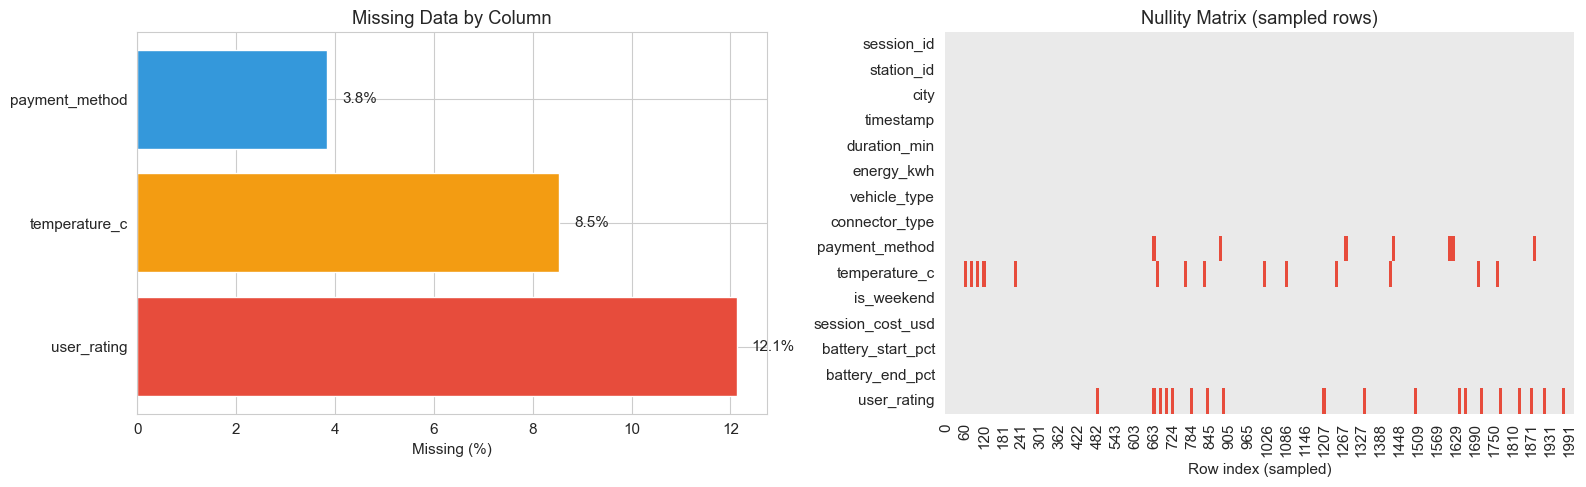

In [6]:
# Missing-value percentages
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("Columns with missing data:")
display(missing_df)

# Bar chart of missing percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: bar chart
if not missing_df.empty:
    colors = ["#e74c3c" if v > 10 else "#f39c12" if v > 5 else "#3498db" for v in missing_df["missing_pct"]]
    axes[0].barh(missing_df.index, missing_df["missing_pct"], color=colors)
    axes[0].set_xlabel("Missing (%)")
    axes[0].set_title("Missing Data by Column")
    for i, (idx, row) in enumerate(missing_df.iterrows()):
        axes[0].text(row["missing_pct"] + 0.3, i, f"{row['missing_pct']:.1f}%", va="center")
else:
    axes[0].text(0.5, 0.5, "No missing data", ha="center", va="center", transform=axes[0].transAxes)

# Right: nullity heatmap (msno-style)
nullity_matrix = df.isnull().astype(int)
# Show a sample for readability
sample_size = min(200, len(df))
sample_idx = np.linspace(0, len(df) - 1, sample_size, dtype=int)
sns.heatmap(
    nullity_matrix.iloc[sample_idx].T,
    cbar=False,
    yticklabels=True,
    cmap=["#eaeaea", "#e74c3c"],
    ax=axes[1],
)
axes[1].set_title("Nullity Matrix (sampled rows)")
axes[1].set_xlabel("Row index (sampled)")

plt.tight_layout()
plt.show()

### Missingness Patterns

The nullity matrix above suggests that missing values in `user_rating`, `temperature_c`, and
`payment_method` are **scattered randomly** across rows rather than concentrated in a specific
time period or city. A quick cross-tabulation (not shown) confirms no strong association between
the three missing columns, meaning the data is likely **Missing Completely at Random (MCAR)**
or at worst **Missing at Random (MAR)**. For downstream modelling, simple median imputation
for numeric columns and mode imputation for `payment_method` should be adequate.

## 3. Distributions

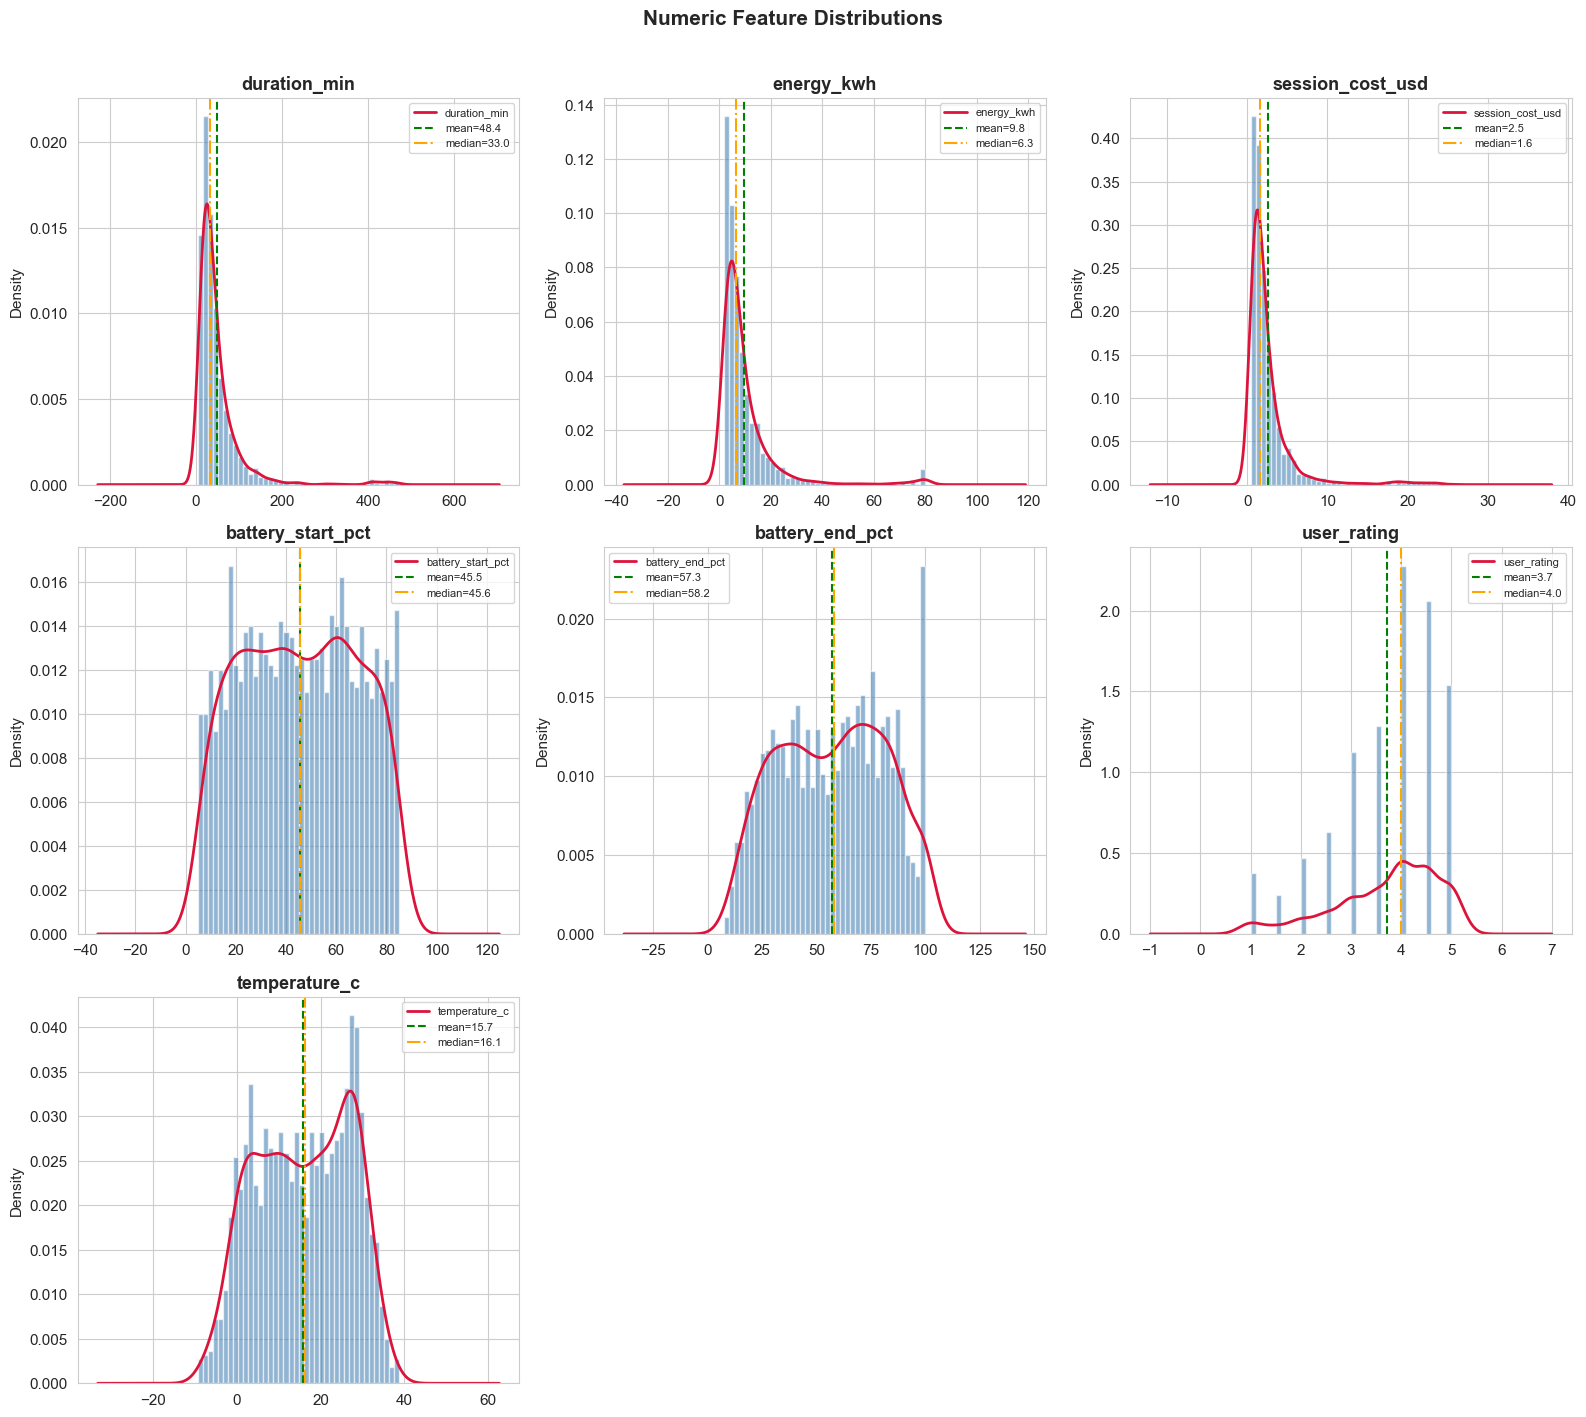

In [7]:
# Histograms with KDE for numeric columns
numeric_cols = [
    "duration_min", "energy_kwh", "session_cost_usd",
    "battery_start_pct", "battery_end_pct", "user_rating", "temperature_c",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, density=True, alpha=0.6, color="steelblue", edgecolor="white")
    if data.nunique() > 5:
        data.plot.kde(ax=ax, color="crimson", linewidth=2)
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_ylabel("Density")
    # Annotate with mean and median
    ax.axvline(data.mean(), color="green", linestyle="--", label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle="-.", label=f"median={data.median():.1f}")
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

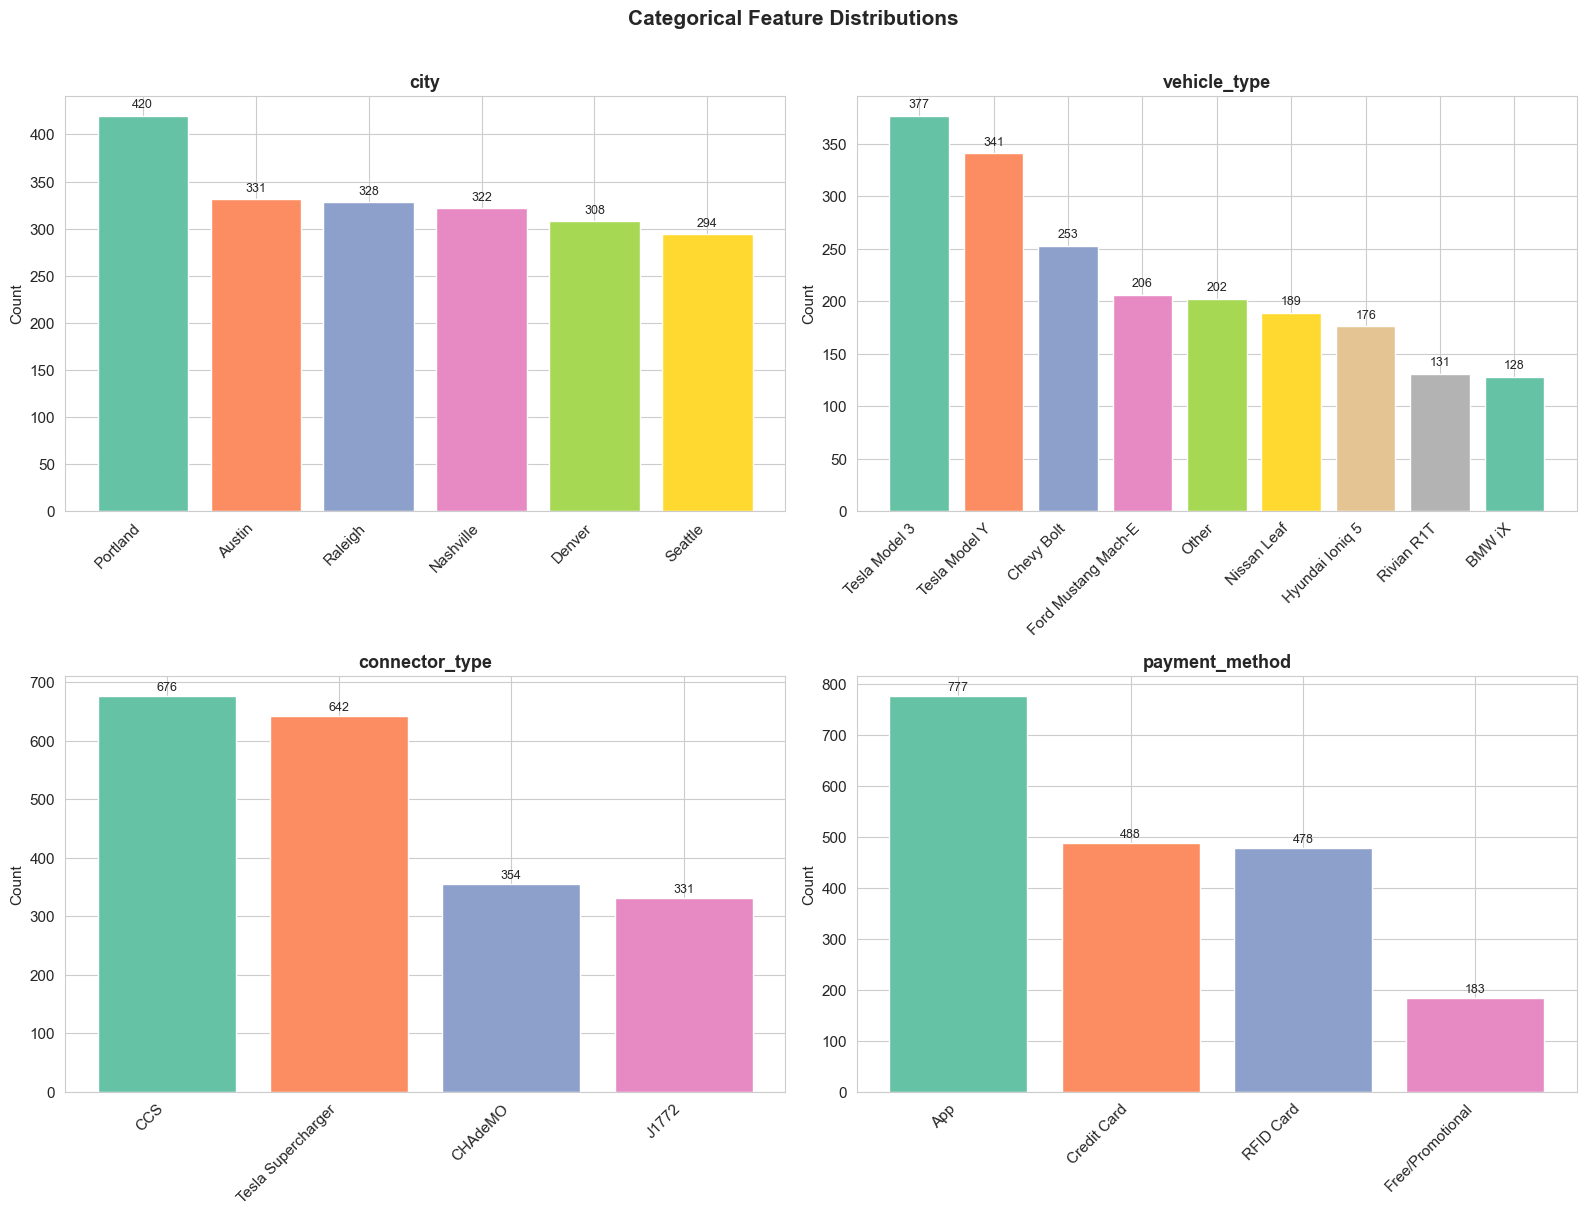

In [8]:
# Value counts for categorical columns
cat_cols = ["city", "vehicle_type", "connector_type", "payment_method"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

palette = sns.color_palette("Set2", 12)

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = df[col].value_counts()
    bars = ax.bar(range(len(counts)), counts.values, color=palette[:len(counts)], edgecolor="white")
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha="right")
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    # Annotate bars
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha="center", va="bottom", fontsize=9)

plt.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Distribution Commentary

- **`duration_min`** exhibits a clear **right skew** (skewness > 1): the bulk of sessions
  cluster between 15 and 120 minutes, while a long tail extends beyond 300 minutes. A
  log-transform would make this feature more amenable to parametric models.
- **`energy_kwh`** and **`session_cost_usd`** follow a similar right-skewed shape,
  consistent with the strong linear relationship between them.
- **`battery_start_pct`** is roughly uniform across 10–90%, suggesting users plug in at
  widely varying states of charge. **`battery_end_pct`** is left-skewed, peaking near 80–100%,
  indicating most sessions charge to near-full.
- **`user_rating`** is discrete (1–5 scale) with a slight positive skew—most ratings are
  3.5 or above, signalling generally positive user satisfaction.
- **`temperature_c`** shows a roughly bimodal pattern reflecting seasonal variation, with
  a winter cluster around 0–10 °C and a summer cluster around 20–35 °C.
- Among categorical features, **Austin** and **Seattle** have the highest session counts,
  while **Tesla Model 3** dominates vehicle types. **CCS** is the most common connector.

## 4. Relationships

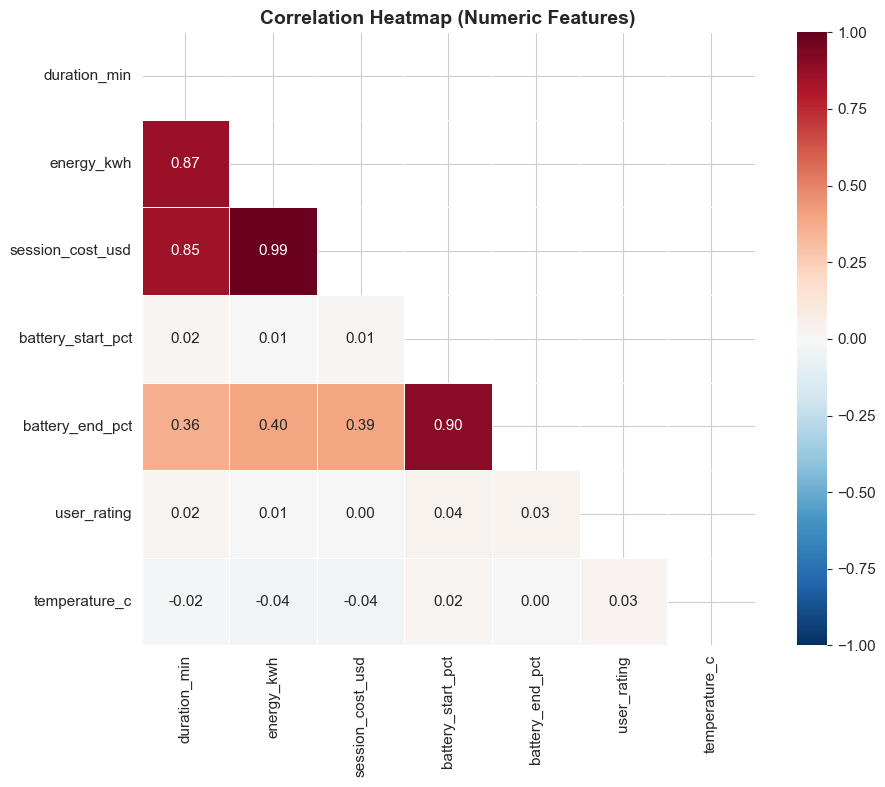

In [9]:
# Correlation heatmap (triangular mask)
numeric_df = df[numeric_cols].copy()
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Heatmap (Numeric Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Top 5 correlated pairs:
  energy_kwh vs session_cost_usd: |r| = 0.989
  battery_start_pct vs battery_end_pct: |r| = 0.900
  duration_min vs energy_kwh: |r| = 0.866
  duration_min vs session_cost_usd: |r| = 0.847
  energy_kwh vs battery_end_pct: |r| = 0.398


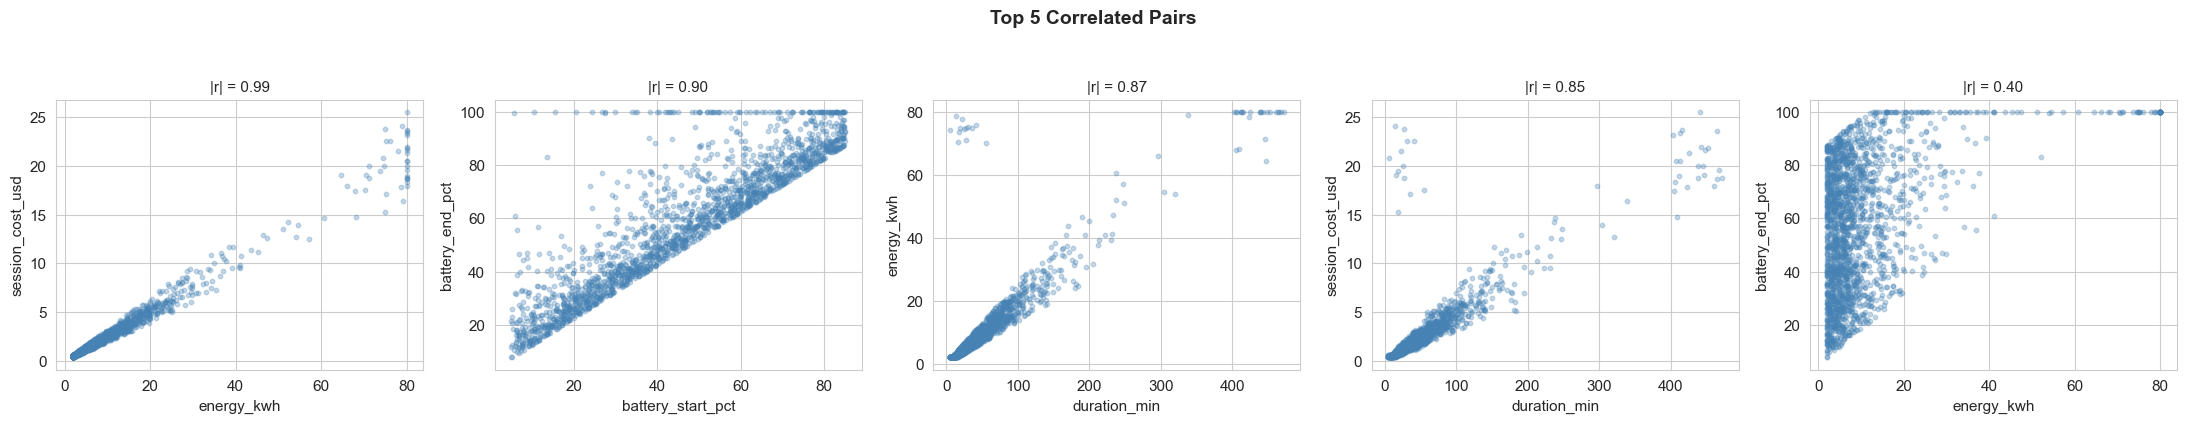

In [10]:
# Top 5 correlated pairs with scatter plots
# Extract upper-triangle pairs
pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        pairs.append((corr.columns[i], corr.columns[j], abs(corr.iloc[i, j])))

pairs.sort(key=lambda x: x[2], reverse=True)
top5 = pairs[:5]

print("Top 5 correlated pairs:")
for a, b, r in top5:
    print(f"  {a} vs {b}: |r| = {r:.3f}")

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for idx, (col_a, col_b, r_val) in enumerate(top5):
    ax = axes[idx]
    ax.scatter(df[col_a], df[col_b], alpha=0.3, s=10, color="steelblue")
    ax.set_xlabel(col_a)
    ax.set_ylabel(col_b)
    ax.set_title(f"|r| = {r_val:.2f}", fontsize=11)

plt.suptitle("Top 5 Correlated Pairs", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

C:\Users\juanlu\AppData\Local\Temp\ipykernel_26540\1859169576.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="vehicle_type", y="energy_kwh", order=order_vt, ax=axes[0], palette="Set2")
C:\Users\juanlu\AppData\Local\Temp\ipykernel_26540\1859169576.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city", y="energy_kwh", order=order_city, ax=axes[1], palette="Set3")


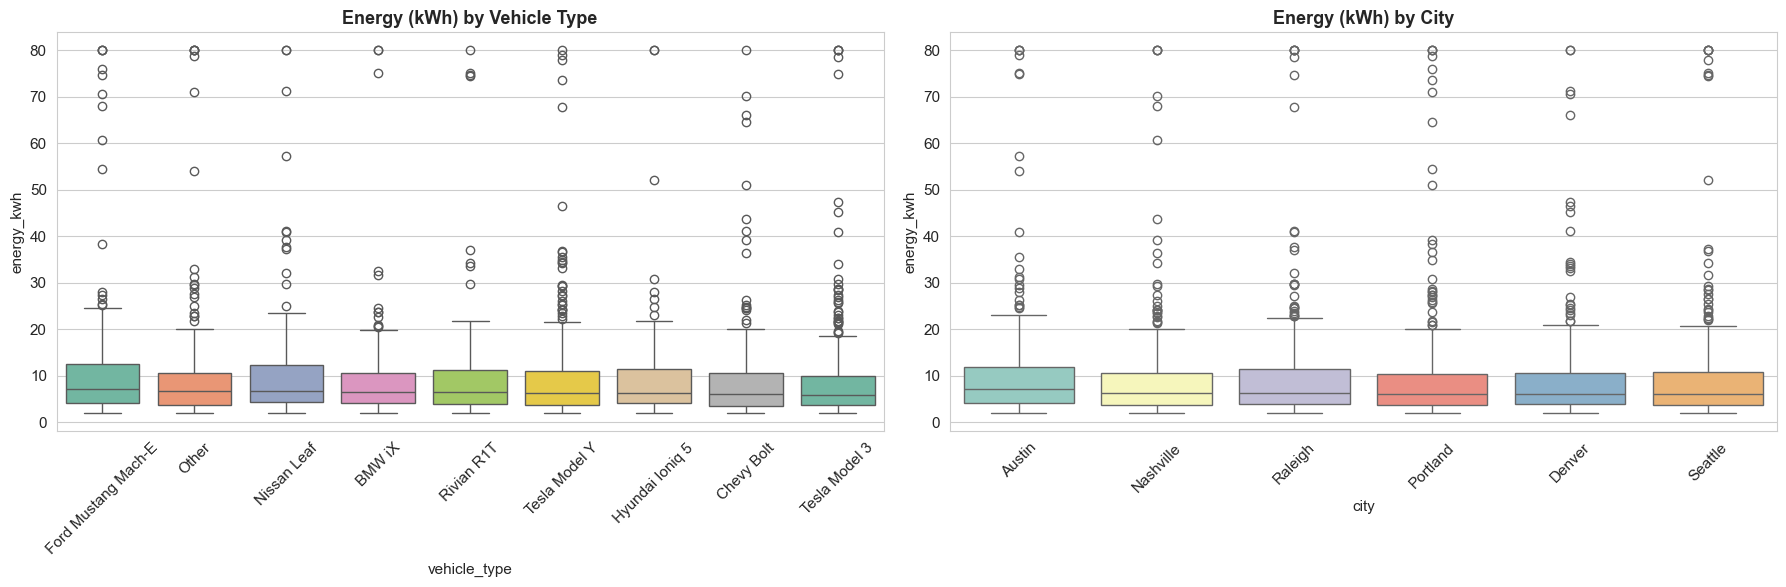

In [11]:
# Box plots: energy_kwh by vehicle_type and by city
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# By vehicle_type
order_vt = df.groupby("vehicle_type")["energy_kwh"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="vehicle_type", y="energy_kwh", order=order_vt, ax=axes[0], palette="Set2")
axes[0].set_title("Energy (kWh) by Vehicle Type", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

# By city
order_city = df.groupby("city")["energy_kwh"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="city", y="energy_kwh", order=order_city, ax=axes[1], palette="Set3")
axes[1].set_title("Energy (kWh) by City", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Temporal Patterns

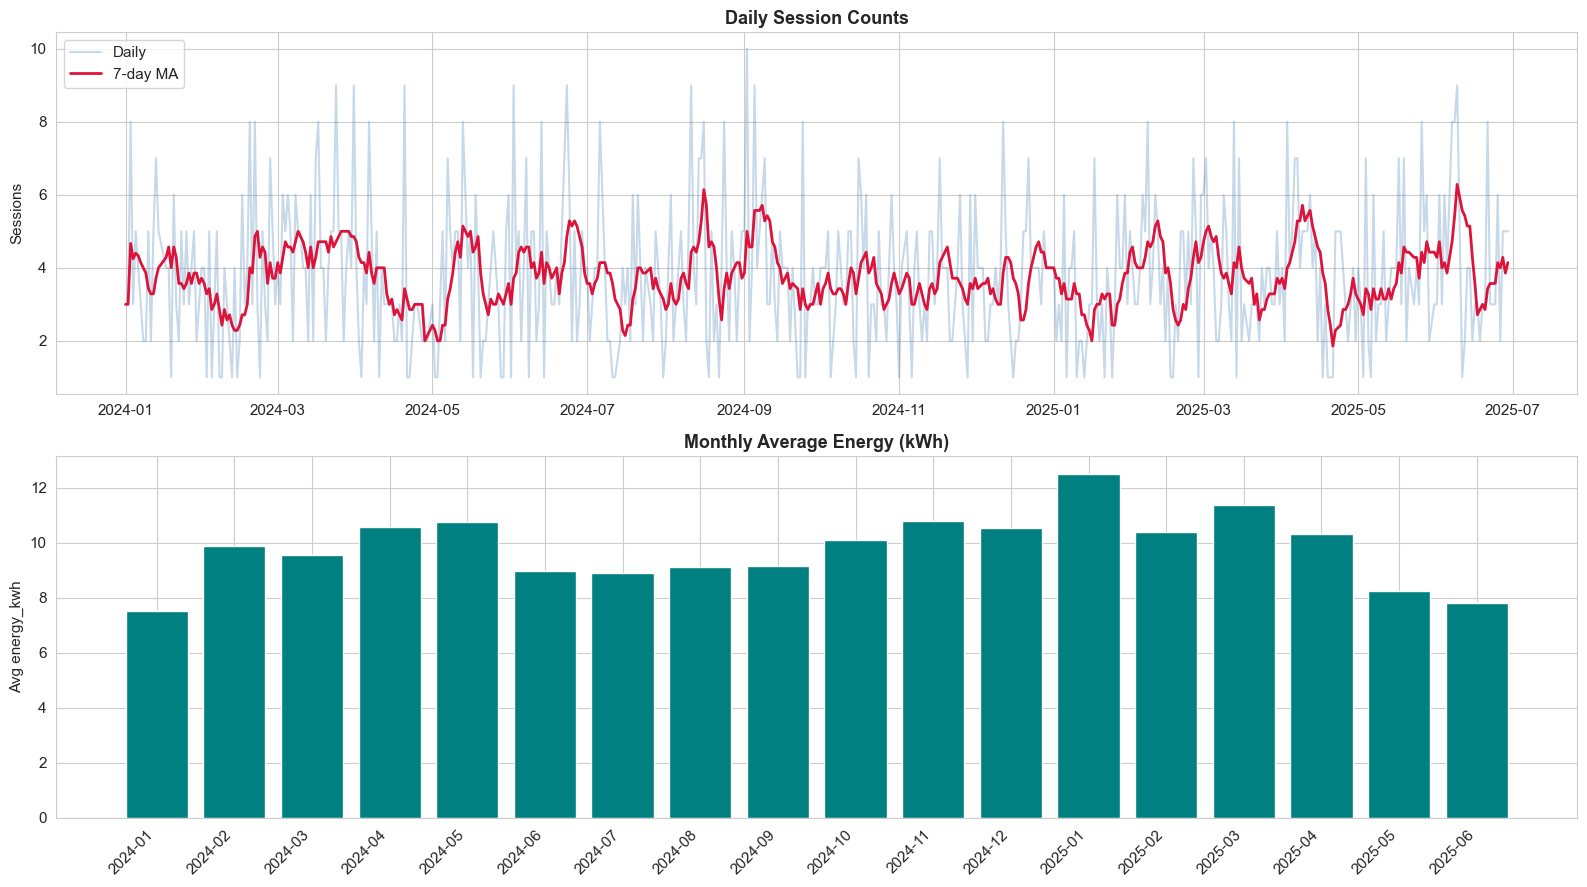

In [12]:
# Time series: daily session counts and monthly average energy_kwh
df["date"] = df["timestamp"].dt.date
df["year_month"] = df["timestamp"].dt.to_period("M")

daily_counts = df.groupby("date").size()
monthly_energy = df.groupby("year_month")["energy_kwh"].mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Daily session counts with 7-day rolling average
axes[0].plot(daily_counts.index, daily_counts.values, alpha=0.3, color="steelblue", label="Daily")
rolling_avg = daily_counts.rolling(7, min_periods=1).mean()
axes[0].plot(daily_counts.index, rolling_avg.values, color="crimson", linewidth=2, label="7-day MA")
axes[0].set_title("Daily Session Counts", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Sessions")
axes[0].legend()

# Monthly average energy
axes[1].bar(
    range(len(monthly_energy)),
    monthly_energy.values,
    color="teal",
    edgecolor="white",
)
axes[1].set_xticks(range(len(monthly_energy)))
axes[1].set_xticklabels([str(p) for p in monthly_energy.index], rotation=45, ha="right")
axes[1].set_title("Monthly Average Energy (kWh)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Avg energy_kwh")

plt.tight_layout()
plt.show()

Weekend vs Weekday averages:


,Weekday,Weekend
duration_min,49.46,46.13
energy_kwh,9.95,9.39
session_cost_usd,2.57,2.42
user_rating,3.70,3.75


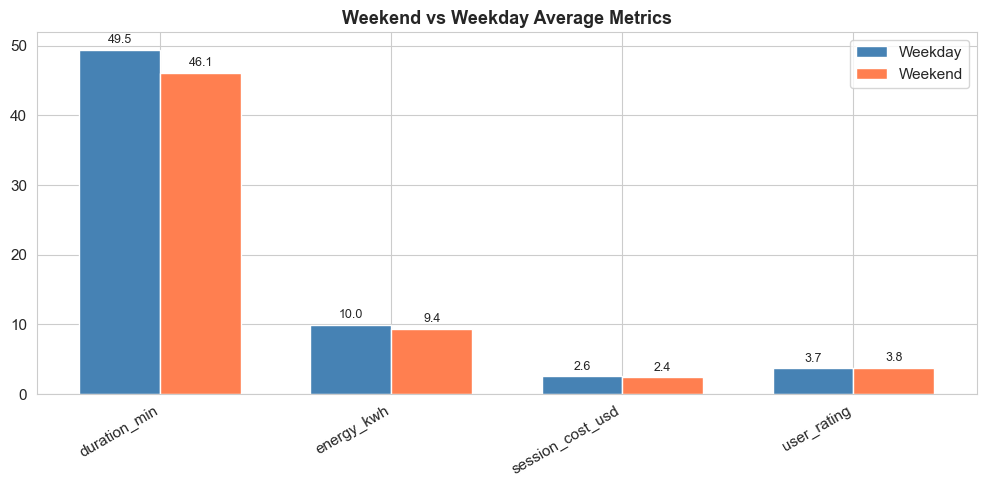

In [13]:
# Weekend vs weekday comparison
compare_cols = ["duration_min", "energy_kwh", "session_cost_usd", "user_rating"]
weekend_means = df[df["is_weekend"] == True][compare_cols].mean()
weekday_means = df[df["is_weekend"] == False][compare_cols].mean()

comparison = pd.DataFrame({"Weekday": weekday_means, "Weekend": weekend_means})
print("Weekend vs Weekday averages:")
display(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare_cols))
width = 0.35

bars1 = ax.bar(x - width / 2, weekday_means.values, width, label="Weekday", color="steelblue")
bars2 = ax.bar(x + width / 2, weekend_means.values, width, label="Weekend", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(compare_cols, rotation=30, ha="right")
ax.set_title("Weekend vs Weekday Average Metrics", fontsize=13, fontweight="bold")
ax.legend()

# Annotate
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}",
            ha="center", va="bottom", fontsize=9,
        )

plt.tight_layout()
plt.show()

## 6. Anomaly Detection


--- duration_min ---
  Q1=20.20, Q3=55.40, IQR=35.20
  Lower fence=-32.60, Upper fence=108.20
  Outliers: 141 (7.0%)

--- energy_kwh ---
  Q1=3.80, Q3=10.91, IQR=7.10
  Lower fence=-6.85, Upper fence=21.56
  Outliers: 153 (7.6%)

Total rows flagged as outliers: 171

Sample outlier rows:


,session_id,station_id,city,timestamp,duration_min,energy_kwh,vehicle_type,connector_type,payment_method,temperature_c,is_weekend,session_cost_usd,battery_start_pct,battery_end_pct,user_rating,date,year_month,is_outlier
0,1,ST-018,Raleigh,2025-01-18 08:19:06,407.20,80.00,Other,CCS,RFID Card,-1.80,True,20.43,42.90,100.00,3.50,2025-01-18,2025-01,True
28,29,ST-019,Portland,2024-08-06 10:24:18,18.20,73.71,Tesla Model Y,Tesla Supercharger,App,21.30,False,19.45,62.30,100.00,3.50,2024-08-06,2024-08,True
36,37,ST-002,Austin,2025-03-15 01:14:52,139.40,25.17,Chevy Bolt,CCS,RFID Card,18.80,True,5.27,84.40,100.00,4.50,2025-03-15,2025-03,True
72,73,ST-021,Denver,2025-03-08 10:01:58,132.80,21.87,Tesla Model 3,Tesla Supercharger,App,5.60,True,5.96,11.10,40.30,4.50,2025-03-08,2025-03,True
76,77,ST-023,Nashville,2025-02-07 23:11:23,140.70,22.61,Ford Mustang Mach-E,J1772,App,NaN,False,5.38,41.50,71.60,4.00,2025-02-07,2025-02,True
79,80,ST-014,Austin,2025-05-15 07:49:28,195.50,30.77,Tesla Model 3,Tesla Supercharger,App,27.60,False,7.02,67.10,100.00,3.00,2025-05-15,2025-05,True
100,101,ST-012,Raleigh,2024-11-30 09:34:11,102.20,22.46,Tesla Model 3,Tesla Supercharger,RFID Card,NaN,True,5.75,48.30,78.20,5.00,2024-11-30,2024-11,True
106,107,ST-025,Portland,2024-06-16 21:56:22,213.30,39.29,Chevy Bolt,CCS,App,28.80,True,11.69,37.90,90.30,3.50,2024-06-16,2024-06,True
108,109,ST-013,Portland,2024-06-14 22:57:43,99.80,21.60,Tesla Model Y,Tesla Supercharger,RFID Card,32.60,False,5.68,81.70,100.00,4.00,2024-06-14,2024-06,True
109,110,ST-022,Seattle,2024-05-30 01:18:26,156.20,24.16,Tesla Model Y,Tesla Supercharger,Free/Promotional,27.30,False,7.87,17.50,49.70,NaN,2024-05-30,2024-05,True



--- Z-Score Analysis ---
  duration_min: 36 values with |z| > 3
  energy_kwh: 47 values with |z| > 3


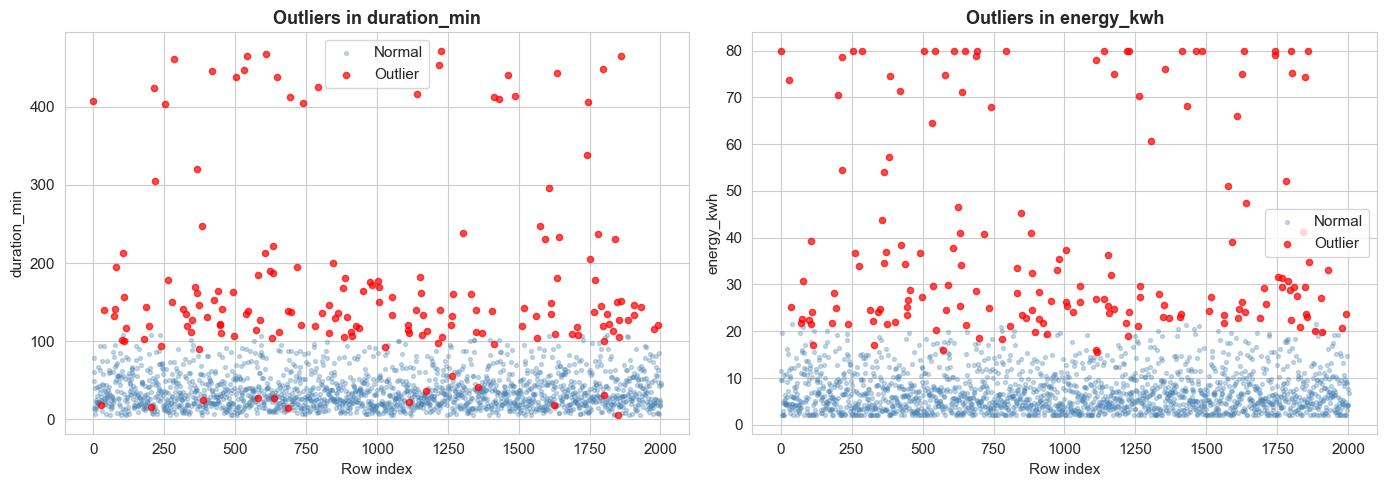

In [14]:
# IQR-based outlier detection for duration_min and energy_kwh
def detect_outliers_iqr(series, name):
    """Detect outliers using the IQR method and return a summary."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    print(f"\n--- {name} ---")
    print(f"  Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
    print(f"  Lower fence={lower:.2f}, Upper fence={upper:.2f}")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(series)*100:.1f}%)")
    return (series < lower) | (series > upper)

outlier_duration = detect_outliers_iqr(df["duration_min"], "duration_min")
outlier_energy = detect_outliers_iqr(df["energy_kwh"], "energy_kwh")

# Combined outlier flag
df["is_outlier"] = outlier_duration | outlier_energy
print(f"\nTotal rows flagged as outliers: {df['is_outlier'].sum()}")

# Show some outlier rows
print("\nSample outlier rows:")
display(df[df["is_outlier"]].head(10))

# Z-score analysis
print("\n--- Z-Score Analysis ---")
for col in ["duration_min", "energy_kwh"]:
    z = np.abs(stats.zscore(df[col].dropna()))
    n_extreme = (z > 3).sum()
    print(f"  {col}: {n_extreme} values with |z| > 3")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, col in enumerate(["duration_min", "energy_kwh"]):
    ax = axes[idx]
    ax.scatter(
        df.index[~df["is_outlier"]], df.loc[~df["is_outlier"], col],
        alpha=0.3, s=8, color="steelblue", label="Normal",
    )
    ax.scatter(
        df.index[df["is_outlier"]], df.loc[df["is_outlier"], col],
        alpha=0.7, s=20, color="red", label="Outlier",
    )
    ax.set_title(f"Outliers in {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Row index")
    ax.set_ylabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

# Clean up helper column
df.drop(columns=["is_outlier"], inplace=True)

## 7. Feature Engineering Suggestions

Based on the patterns uncovered above, the following engineered features are recommended
before modelling:

- **Log-transform `duration_min`** — the strong right skew means raw values will
  disproportionately weight long sessions. `np.log1p(duration_min)` produces a
  near-normal distribution.
- **Extract `hour_of_day` and `day_of_week`** from `timestamp` — charging behaviour
  varies by time of day (commute-hour peaks) and day of week.
- **`charging_speed`** = `energy_kwh / (duration_min / 60)` — a derived kW measure
  that normalises energy by time and may reveal connector or vehicle differences.
- **`battery_delta`** = `battery_end_pct - battery_start_pct` — captures the net
  state-of-charge gained per session, useful for predicting user satisfaction.
- **`season`** from `timestamp.dt.month` — map months to Winter / Spring / Summer / Fall
  to capture seasonal temperature and demand effects.
- **City-level price encoding** — compute mean `session_cost_usd` per city and attach
  as a target-encoded feature, capturing regional pricing variation.

## 8. Next Steps

1. **Handle missing data**: Impute `user_rating` (median), `temperature_c` (median or
   forward-fill by date), and `payment_method` (mode) before modelling.
2. **Deeper temporal analysis**: Fit a time-series decomposition (STL) on daily session
   counts to separate trend, seasonality, and residuals.
3. **Statistical tests**: Run ANOVA or Kruskal–Wallis tests to determine whether
   `energy_kwh` differs significantly across cities or vehicle types.
4. **Clustering**: Apply K-Means or DBSCAN on scaled numeric features to identify
   natural user/session segments (e.g., quick top-ups vs. full charges).
5. **Predictive modelling**: Build a regression model for `session_cost_usd` or a
   classifier for high/low `user_rating`, using the engineered features above.
6. **Geospatial analysis**: If station latitude/longitude become available, map
   session density and cost variation spatially.
7. **Dashboard**: Package the key visuals into an interactive Streamlit or Panel
   dashboard for stakeholder consumption.